<a href="https://colab.research.google.com/github/BatoolAshour/Average_Waiting_Times_At_SaudiAirports/blob/main/Average_Waiting_Times_At_Airport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper

from bidi.algorithm import get_display

%matplotlib inline

# ===== إعداد الخط العربي =====
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12,6)

# ===== دالة تصحيح العربية =====
def ar(text):
    return get_display(arabic_reshaper.reshape(str(text)))


In [41]:
#pip install arabic-reshaper python-bidi

In [42]:
import arabic_reshaper
from bidi.algorithm import get_display

In [43]:
df = pd.read_csv('/content/Average waiting times at airports Q1 2026.csv')

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   السنة                            576 non-null    int64 
 1   الشهر                            576 non-null    int64 
 2   المطار                           576 non-null    object
 3   المعيار                          576 non-null    object
 4   متوسط أوقات الانتظار (بالدقائق)  576 non-null    object
dtypes: int64(2), object(3)
memory usage: 22.6+ KB


In [45]:
df.describe()

,السنة,الشهر
count,576.0,576.000000
mean,2026.0,2.000000
std,0.0,0.817206
min,2026.0,1.000000
25%,2026.0,1.000000
50%,2026.0,2.000000
75%,2026.0,3.000000
max,2026.0,3.000000


In [46]:
df.head()

,السنة,الشهر,المطار,المعيار,متوسط أوقات الانتظار (بالدقائق)
0,2026,1,مطار الملك عبدالعزيز الدولي بجدة,وقت الانتظار عند تسجيل إجراءات السفر,4.0
1,2026,1,مطار الملك عبدالعزيز الدولي بجدة,وقت الانتظار عند التفتيش الأمني,1.5
2,2026,1,مطار الملك عبدالعزيز الدولي بجدة,وقت الانتظار عند معاينة وثائق السفر للمغادرين,1.4
3,2026,1,مطار الملك عبدالعزيز الدولي بجدة,وقت الانتظار عند معاينة وثائق السفر للقادمين,1.8
4,2026,1,مطار الملك عبدالعزيز الدولي بجدة,وقت الانتظار عند التفتيش الجمركي,0.9


In [47]:
df.isnull().sum()

,0
السنة,0
الشهر,0
المطار,0
المعيار,0
متوسط أوقات الانتظار (بالدقائق),0


In [48]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
571,False
572,False
573,False
574,False


In [49]:
df['متوسط أوقات الانتظار (بالدقائق)'] = pd.to_numeric(df['متوسط أوقات الانتظار (بالدقائق)'], errors='coerce')

Text(0, 0.5, 'ﻢﻴﻘﻟﺍ ﺩﺪﻋ')

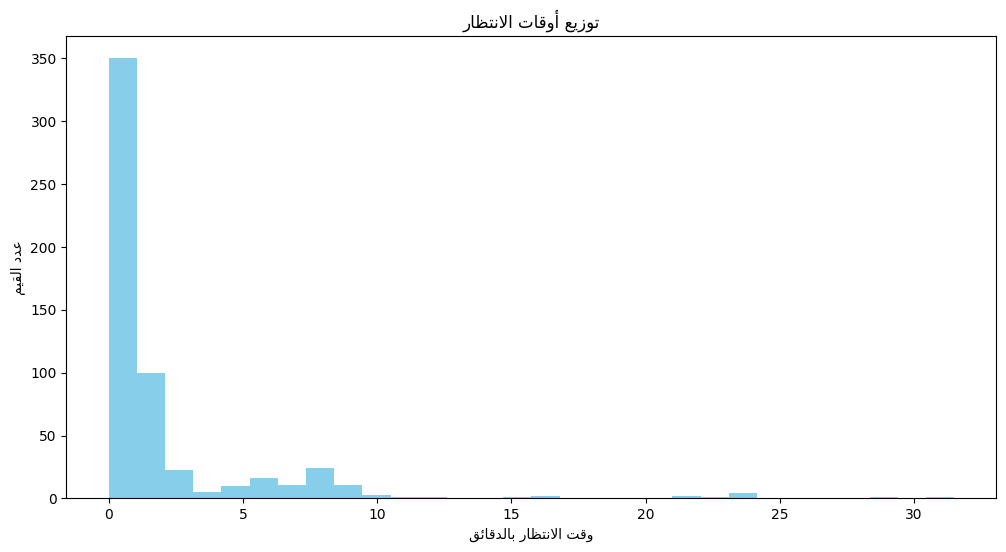

In [56]:
plt.hist(df['متوسط أوقات الانتظار (بالدقائق)'], bins=30, color='skyblue')
plt.title(ar('توزيع أوقات الانتظار'))
plt.xlabel(ar('وقت الانتظار بالدقائق'))
plt.ylabel(ar('عدد القيم'))

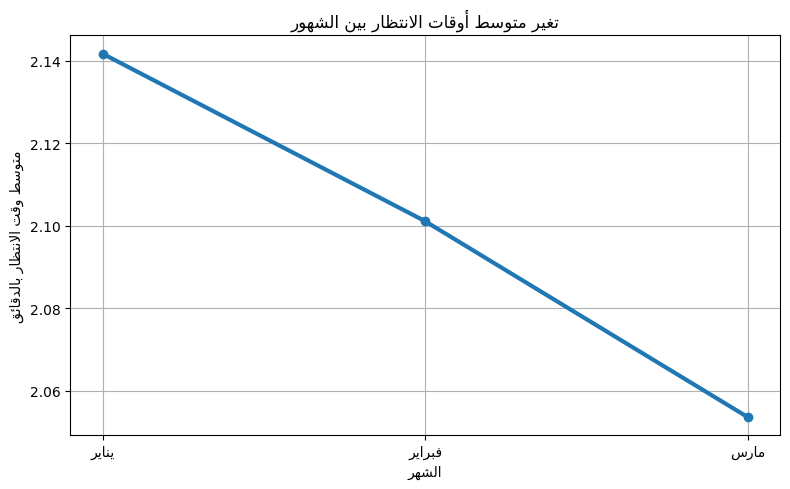

In [75]:
monthly_avg = df.groupby('الشهر')['متوسط أوقات الانتظار (بالدقائق)'].mean()

plt.figure(figsize=(8,5))

plt.plot(
    [ar('يناير'), ar('فبراير'), ar('مارس')],
    monthly_avg.values,
    marker='o',
    linewidth=3
)

plt.title(ar('تغير متوسط أوقات الانتظار بين الشهور'))
plt.xlabel(ar('الشهر'))
plt.ylabel(ar('متوسط وقت الانتظار بالدقائق'))

plt.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4349/1086822276.py:19: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


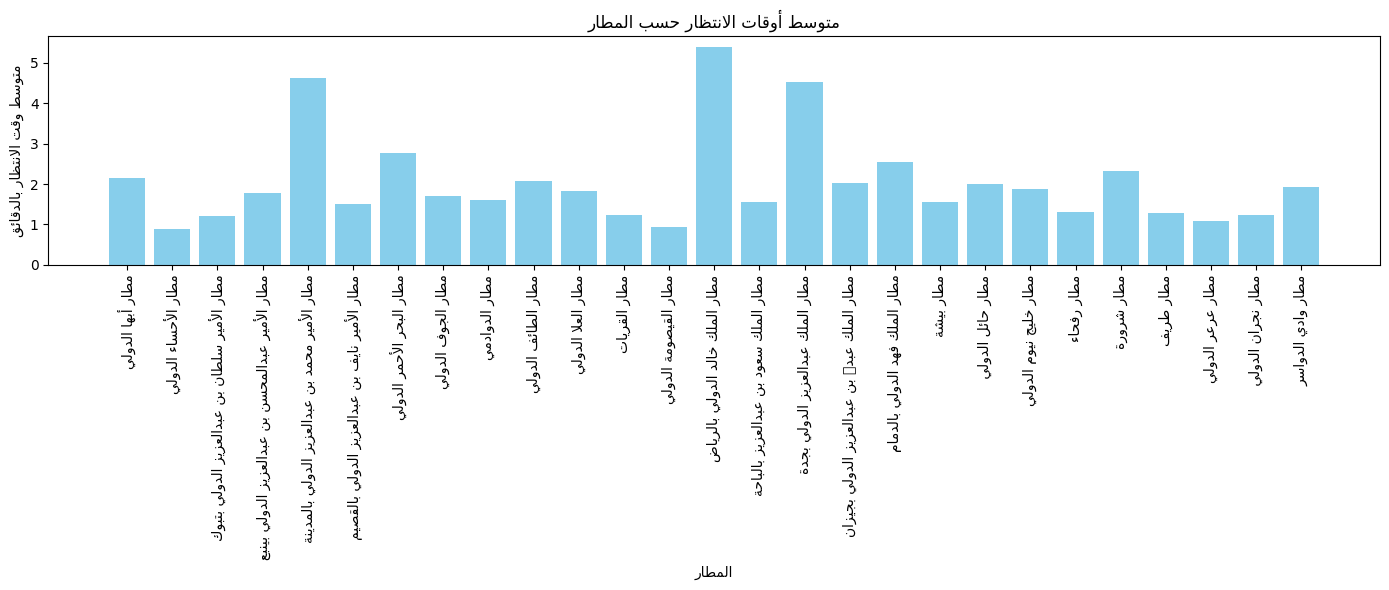

In [57]:
airport_avg = df.groupby('المطار')['متوسط أوقات الانتظار (بالدقائق)'].mean()

labels = [ar(x) for x in airport_avg.index]

plt.figure(figsize=(14,6))

plt.bar(
    labels,
    airport_avg.values,
    color='skyblue'
)

plt.title(ar('متوسط أوقات الانتظار حسب المطار'))
plt.xlabel(ar('المطار'))
plt.ylabel(ar('متوسط وقت الانتظار بالدقائق'))

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

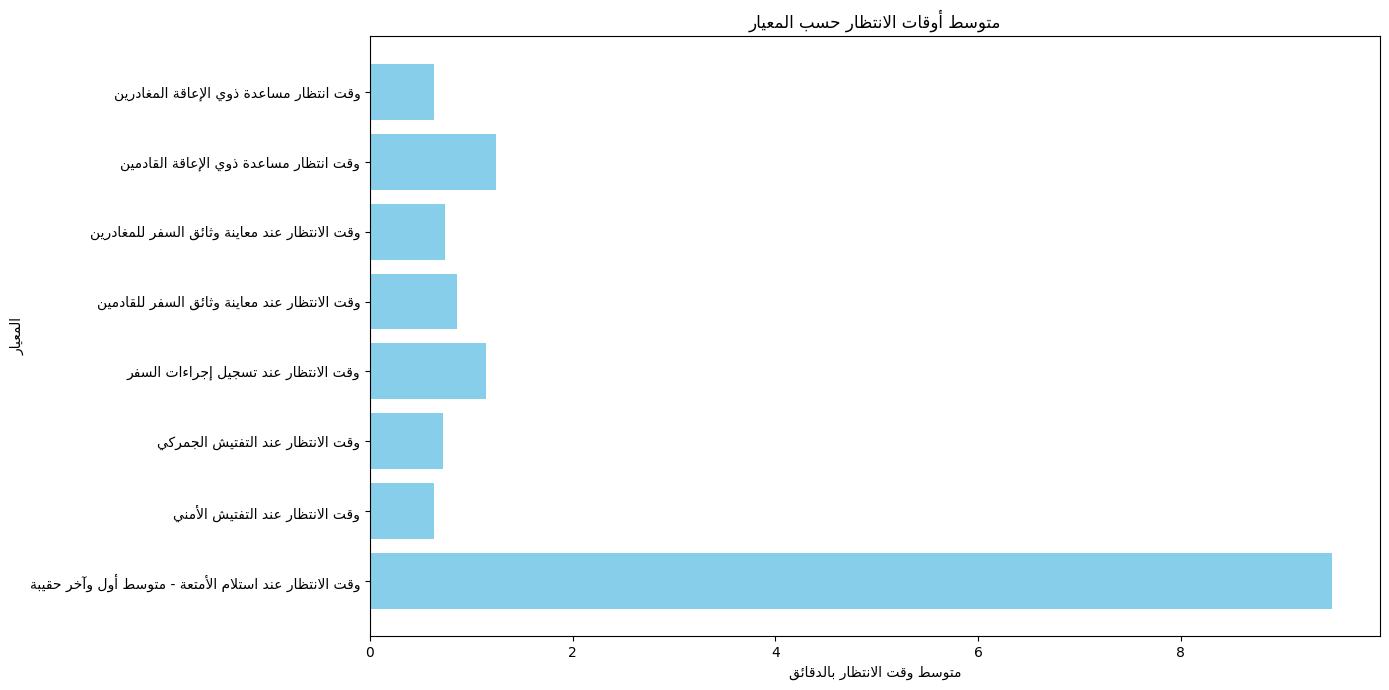

In [59]:
criteria_avg = df.groupby('المعيار')['متوسط أوقات الانتظار (بالدقائق)'].mean()

labels = [ar(x) for x in criteria_avg.index]

plt.figure(figsize=(14,7))

plt.barh(
    labels,
    criteria_avg.values,
    color='skyblue'
)

plt.title(ar('متوسط أوقات الانتظار حسب المعيار'))
plt.xlabel(ar('متوسط وقت الانتظار بالدقائق'))
plt.ylabel(ar('المعيار'))

plt.tight_layout()
plt.show()

/tmp/ipykernel_4349/1954256555.py:22: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


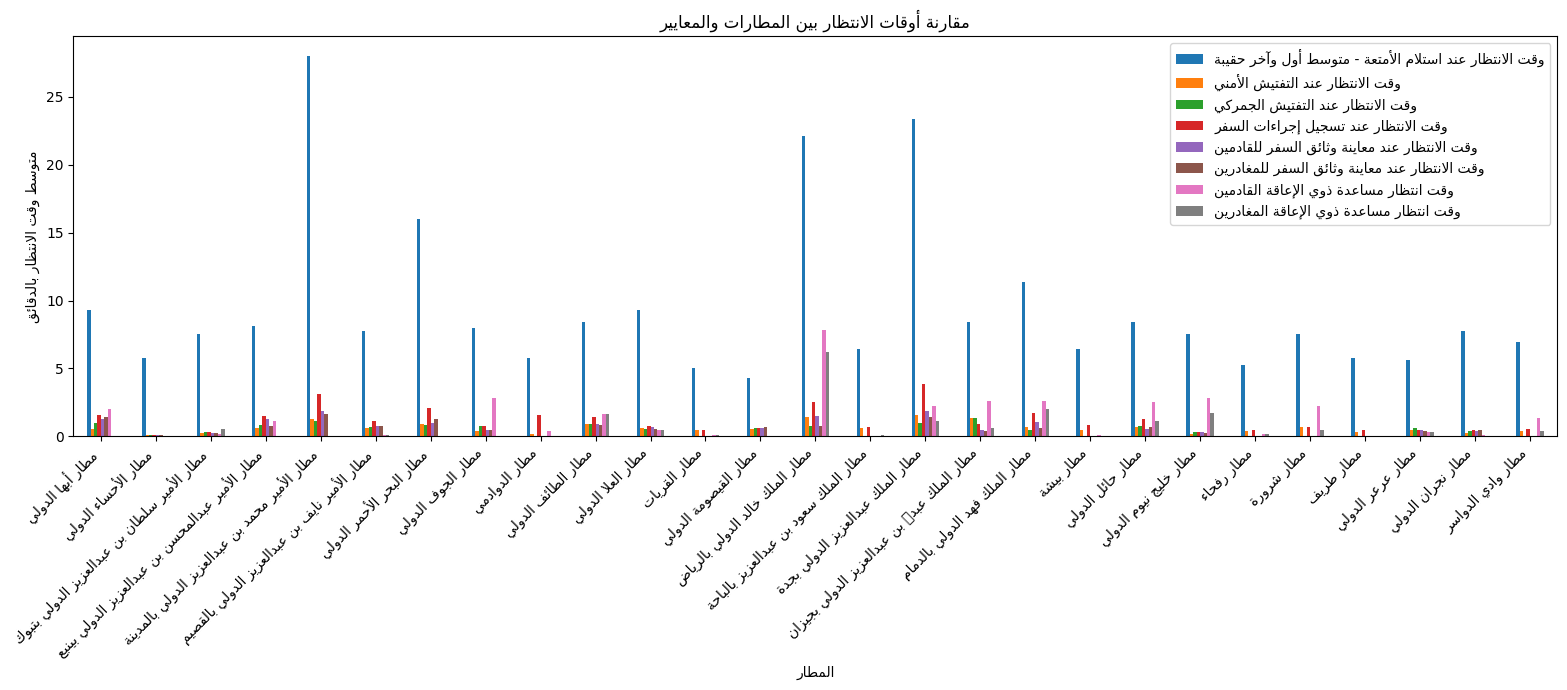

In [60]:
pivot_df = df.pivot_table(
    index='المطار',
    columns='المعيار',
    values='متوسط أوقات الانتظار (بالدقائق)',
    aggfunc='mean'
)

pivot_df.index = [ar(x) for x in pivot_df.index]
pivot_df.columns = [ar(x) for x in pivot_df.columns]

pivot_df.plot(
    kind='bar',
    figsize=(16,7)
)

plt.title(ar('مقارنة أوقات الانتظار بين المطارات والمعايير'))
plt.xlabel(ar('المطار'))
plt.ylabel(ar('متوسط وقت الانتظار بالدقائق'))

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4349/1145286506.py:20: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


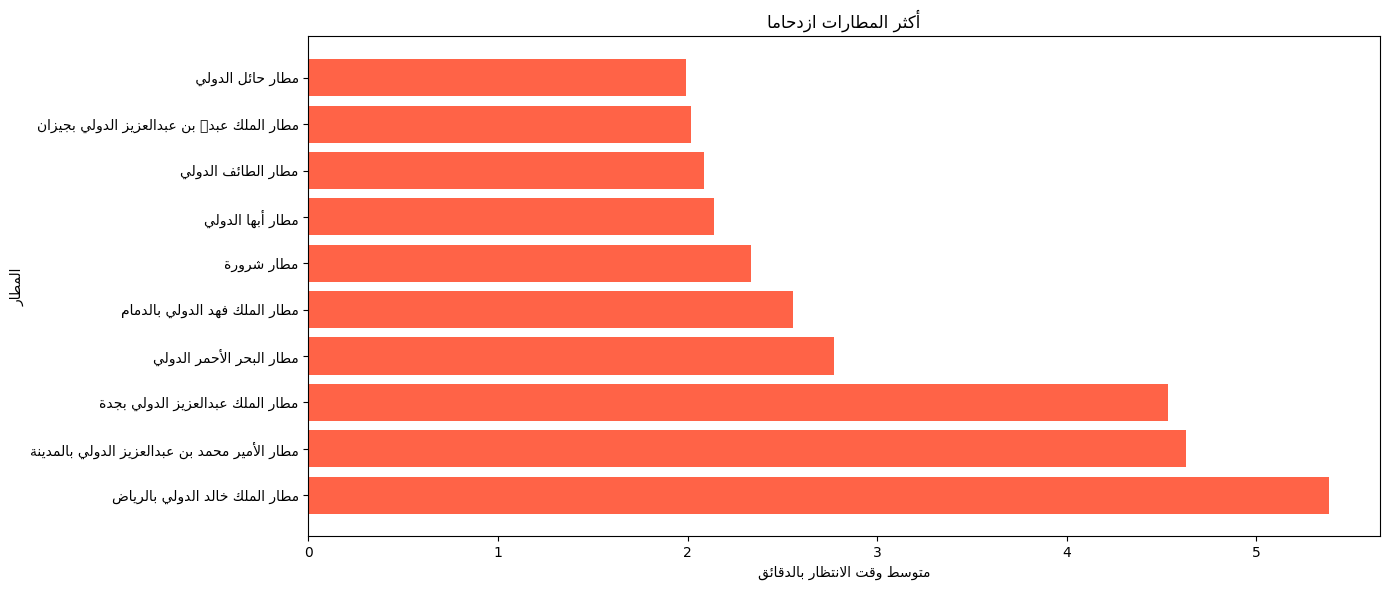

In [64]:
top_airports = df.groupby('المطار')['متوسط أوقات الانتظار (بالدقائق)'] \
                 .mean() \
                 .sort_values(ascending=False) \
                 .head(10)

labels = [ar(x) for x in top_airports.index]

plt.figure(figsize=(14,6))

plt.barh(
    labels,
    top_airports.values,
    color='tomato'
)

plt.title(ar('أكثر المطارات ازدحامًا'))
plt.xlabel(ar('متوسط وقت الانتظار بالدقائق'))
plt.ylabel(ar('المطار'))

plt.tight_layout()
plt.show()

In [72]:
#Best Performing Airports
best = df.groupby('المطار')['متوسط أوقات الانتظار (بالدقائق)'].mean().sort_values().head()

print(('أفضل 5 مطارات من ناحية السرعة:'))
print(best)

أفضل 5 مطارات من ناحية السرعة:
المطار
مطار الأحساء الدولي                            0.885714
مطار القيصومة الدولي                           0.929167
مطار عرعر الدولي                               1.091667
مطار الأمير سلطان بن عبدالعزيز الدولي بتبوك    1.212500
مطار نجران الدولي                              1.237500
Name: متوسط أوقات الانتظار (بالدقائق), dtype: float64


In [71]:
#ً Worst performing airport
worst = df.groupby('المطار')['متوسط أوقات الانتظار (بالدقائق)'].mean().sort_values(ascending=False).head()

print((' أسوأ 5 مطارات من ناحية السرعة:'))
print(worst)

 أسوأ 5 مطارات من ناحية السرعة:
المطار
مطار الملك خالد الدولي بالرياض                   5.383333
مطار الأمير محمد بن عبدالعزيز الدولي بالمدينة    4.629167
مطار الملك عبدالعزيز الدولي بجدة                 4.533333
مطار البحر الأحمر الدولي                         2.770833
مطار الملك فهد الدولي بالدمام                    2.554167
Name: متوسط أوقات الانتظار (بالدقائق), dtype: float64


In [70]:
# Most Delaying معيار
criteria_avg = df.groupby('المعيار')['متوسط أوقات الانتظار (بالدقائق)'] \
                 .mean() \
                 .sort_values(ascending=False)
print(criteria_avg)

المعيار
وقت الانتظار عند استلام الأمتعة - متوسط أول وآخر حقيبة    9.490123
وقت انتظار مساعدة ذوي الإعاقة القادمين                    1.248148
وقت الانتظار عند تسجيل إجراءات السفر                      1.145679
وقت الانتظار عند معاينة وثائق السفر للقادمين              0.857407
وقت الانتظار عند معاينة وثائق السفر للمغادرين             0.744444
وقت الانتظار عند التفتيش الجمركي                          0.718519
وقت الانتظار عند التفتيش الأمني                           0.633333
وقت انتظار مساعدة ذوي الإعاقة المغادرين                   0.632099
Name: متوسط أوقات الانتظار (بالدقائق), dtype: float64
